In [2]:
import pandas as pd
import utils

In [3]:
order_reviews_dataset = pd.read_csv("./dataset/olist_order_reviews_dataset.csv")
orders_dataset = pd.read_csv("./dataset/olist_orders_dataset.csv")
order_items_dataset = pd.read_csv("./dataset/olist_order_items_dataset.csv")

In [4]:
orders_dataset['order_delivered_customer_date'] = pd.to_datetime(orders_dataset['order_delivered_customer_date'])
orders_dataset['order_estimated_delivery_date'] = pd.to_datetime(orders_dataset['order_estimated_delivery_date'])

orders_dataset = orders_dataset[orders_dataset['order_status'] == 'delivered']

orders_dataset.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'], inplace= True)

orders_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [5]:
orders_dataset['delay'] = (orders_dataset['order_delivered_customer_date'] - orders_dataset['order_estimated_delivery_date']).dt.days

orders_dataset['delay']

0        -8
1        -6
2       -18
3       -13
4       -10
         ..
99436   -11
99437    -2
99438    -6
99439   -21
99440   -18
Name: delay, Length: 96470, dtype: int64

In [6]:
orders_dataset['is_late'] = (orders_dataset['delay'] > 0).astype(int)

orders_dataset['is_late']

0        0
1        0
2        0
3        0
4        0
        ..
99436    0
99437    0
99438    0
99439    0
99440    0
Name: is_late, Length: 96470, dtype: int64

In [7]:
items_agg = order_items_dataset.groupby('order_id').agg(
    freight_value = ('freight_value', 'sum'),
    price = ('price', 'sum')
).reset_index()

# Cap price outliers at IQR bounds (per stated cleaning plan)
Q1 = items_agg['price'].quantile(0.25)
Q3 = items_agg['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

items_agg['price'] = items_agg['price'].clip(lower=lower_bound, upper=upper_bound)

orders_dataset = orders_dataset.merge(items_agg, on= 'order_id')

# Impute missing review_score with the mean (per stated cleaning plan)
order_reviews_dataset['review_score'] = order_reviews_dataset['review_score'].fillna(
    order_reviews_dataset['review_score'].mean()
)

order_reviews_dataset['is_satisfied'] = (order_reviews_dataset['review_score'] >= 4).astype(int)

merged = pd.merge(orders_dataset, order_reviews_dataset, on= 'order_id')

merged.drop(columns= ['review_comment_title', 'review_comment_message'], inplace= True)

In [8]:
utils.missing_value_report(merged)

,missing_count,missing_pct
order_approved_at,14,0.01
order_delivered_carrier_date,1,0.00
order_id,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_purchase_timestamp,0,0.00
order_delivered_customer_date,0,0.00
order_estimated_delivery_date,0,0.00
delay,0,0.00
is_late,0,0.00


In [9]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 96353 entries, 0 to 96352
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96353 non-null  str           
 1   customer_id                    96353 non-null  str           
 2   order_status                   96353 non-null  str           
 3   order_purchase_timestamp       96353 non-null  str           
 4   order_approved_at              96339 non-null  str           
 5   order_delivered_carrier_date   96352 non-null  str           
 6   order_delivered_customer_date  96353 non-null  datetime64[us]
 7   order_estimated_delivery_date  96353 non-null  datetime64[us]
 8   delay                          96353 non-null  int64         
 9   is_late                        96353 non-null  int64         
 10  freight_value                  96353 non-null  float64       
 11  price                     

In [10]:
X = merged[['delay', 'is_late', 'freight_value', 'price']]
y = merged['is_satisfied']

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 67)

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, class_weight= 'balanced', random_state=67)
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['delay','is_late','freight_value','price']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [12]:
y_predict = pipeline.predict(X_test)

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_predict, zero_division=0))
print(confusion_matrix(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.50      0.33      0.40      6187
           1       0.83      0.91      0.87     22719

    accuracy                           0.79     28906
   macro avg       0.67      0.62      0.63     28906
weighted avg       0.76      0.79      0.77     28906

[[ 2047  4140]
 [ 2052 20667]]


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state= 67, class_weight= 'balanced')

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",67
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [ ]:
y_predict = dt_model.predict(X_test)

print(classification_report(y_test, y_predict, zero_division= 0))
print(confusion_matrix(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.33      0.36      0.34      6187
           1       0.82      0.80      0.81     22719

    accuracy                           0.71     28906
   macro avg       0.58      0.58      0.58     28906
weighted avg       0.72      0.71      0.71     28906

[[ 2230  3957]
 [ 4543 18176]]


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight= 'balanced', random_state= 67)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",67
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [ ]:
y_predict = rf_model.predict(X_test)

print(classification_report(y_test, y_predict, zero_division= 0))
print(confusion_matrix(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.36      0.39      0.38      6187
           1       0.83      0.81      0.82     22719

    accuracy                           0.72     28906
   macro avg       0.60      0.60      0.60     28906
weighted avg       0.73      0.72      0.73     28906

[[ 2435  3752]
 [ 4257 18462]]


In [18]:
import seaborn as sns

<Axes: >

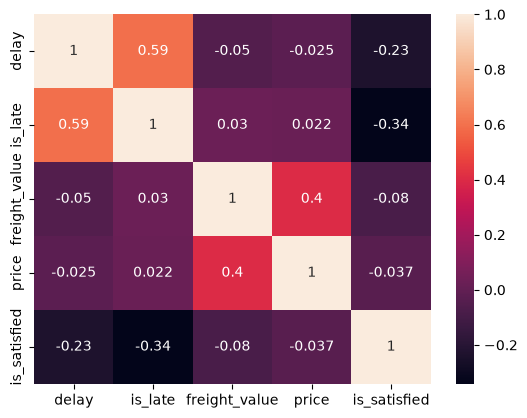

In [19]:
sns.heatmap(merged[['delay', 'is_late', 'freight_value', 'price', 'is_satisfied']].corr(), annot= True)

In [1]:
import numpy

def print_cross_validation_accuracy(scores: numpy.ndarray, show_approximated: bool = True) -> None:

    print("Score: ")

    if show_approximated:
        for i in range(0, scores.size - 1):
            print(f"[{i}]: {scores[i]:.3f}")
            
        print(f"Average Accuracy: {scores.mean():.3f} \nSTD: {scores.std():.3f}")

        return

    for i in range(0, scores.size - 1):
        print(f"[{i}]: {scores[i]}")
        
    print(f"Average Accuracy: {scores.mean()} \nSTD: {scores.std()}")

    

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=10)

print_cross_validation_accuracy(cv_scores)

Score: 
[0]: 0.789
[1]: 0.792
[2]: 0.784
[3]: 0.791
[4]: 0.788
[5]: 0.782
[6]: 0.788
[7]: 0.788
[8]: 0.791
Average Accuracy: 0.788 
STD: 0.003


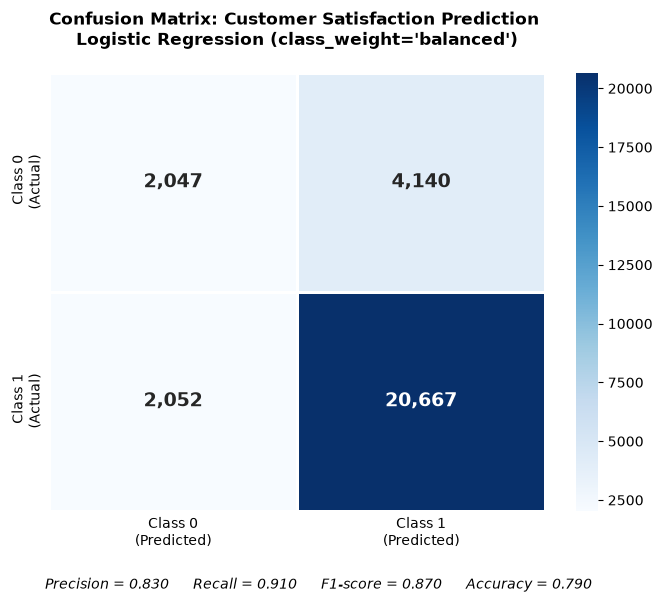

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix data from the provided report (image_db7a1c.png)
cm = np.array([[2047, 4140],
               [2052, 20667]])

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create the heatmap to match the exact style (Screenshot 2026-09-03 103102.png)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            linewidths=2, linecolor='white',
            cbar=True, 
            annot_kws={'weight': 'bold', 'size': 14},
            ax=ax)

# Configure axes labels to match the style format
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Class 0\n(Predicted)', 'Class 1\n(Predicted)'])

ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Class 0\n(Actual)', 'Class 1\n(Actual)'], va='center')

# Remove axis ticks
ax.tick_params(axis='both', which='both', length=0)

# Metrics from the report (using Class 1 and overall Accuracy)
precision = 0.83
recall = 0.91
f1_score = 0.87
accuracy = 0.79

# Add metrics text at the bottom matching the italicized style
metrics_text = f"Precision = {precision:.3f}      Recall = {recall:.3f}      F1-score = {f1_score:.3f}      Accuracy = {accuracy:.3f}"
plt.figtext(0.12, 0.02, metrics_text, ha='left', fontsize=10, style='italic')

# Adjust layout to make room for the text at the bottom and match proportions
plt.subplots_adjust(bottom=0.15)

plt.title("Confusion Matrix: Customer Satisfaction Prediction \nLogistic Regression (class_weight='balanced')", fontweight='bold', pad=20)

# Display the plot
plt.show()

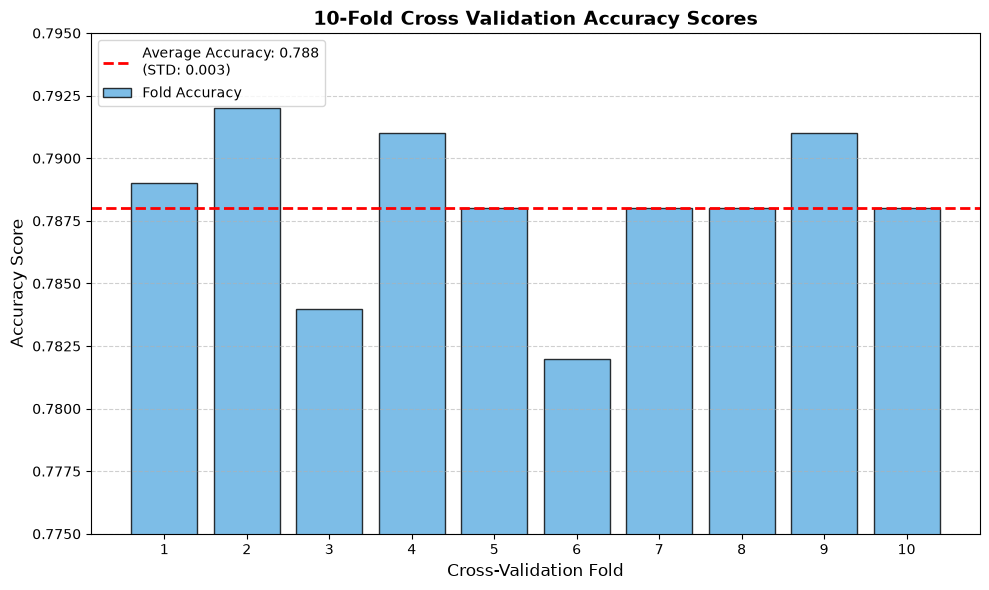

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the image
cv_scores = [0.789, 0.792, 0.784, 0.791, 0.788, 0.782, 0.788, 0.788, 0.791, 0.788]
folds = np.arange(1, 11)
mean_accuracy = 0.788
std_dev = 0.003

# Create the figure
plt.figure(figsize=(10, 6))

# Create a bar chart for each fold's score
plt.bar(folds, cv_scores, color='#5DADE2', edgecolor='black', alpha=0.8, label='Fold Accuracy')

# Add a horizontal line for the average accuracy
plt.axhline(y=mean_accuracy, color='red', linestyle='--', linewidth=2, 
            label=f'Average Accuracy: {mean_accuracy:.3f}\n(STD: {std_dev:.3f})')

# Set y-axis limits to zoom in on the variance (since scores are tightly clustered)
plt.ylim(0.775, 0.795)

# Add labels and title
plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('10-Fold Cross Validation Accuracy Scores', fontsize=14, fontweight='bold')

# Ensure all 10 folds are labeled on the x-axis
plt.xticks(folds)

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add legend
plt.legend(loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()
